In [10]:
import jax
device = "cuda" # must be cpu or cuda
jax.config.update("jax_platform_name", device)
print("Default device:", jax.devices())
from jax import random
from jax import numpy as jnp
# from qvarnet.sampler import mh_chain
import time
import matplotlib.pyplot as plt
from functools import partial


@partial(jax.jit, static_argnames=("prob_fn",))
def mh_chain(random_values, prob_fn, init_pos):
    # Placeholder implementation of mh_chain
    
    def mh_kernel(carry, random_values):
        position, old_prob = carry
        proposal = position + (2 * random_values[0] - 1)
        proposal_prob = prob_fn(proposal)
        accept_prob = jnp.minimum(1.0, proposal_prob / old_prob)
        accept = random_values[-1] < accept_prob
        new_position = jnp.where(accept, proposal, position)
        new_prob = jnp.where(accept, proposal_prob, old_prob)
        carry = (new_position, new_prob)
        return carry, new_position

    initial_prob = prob_fn(init_pos)
    carry = (init_pos, initial_prob)
    positions, _ = jax.lax.scan(mh_kernel, carry, random_values)
    return positions


sampler = jax.vmap(
        mh_chain,
        in_axes=(
            0,
            None,
            0,
        ),  # random_values, prob_fn, init_position
        out_axes=0,
    )

Default device: [CpuDevice(id=0)]


In [11]:
@jax.jit
def prob_fn(positions):
    """A simple probability function: a Gaussian centered at the origin."""
    return jnp.exp(-0.5*jnp.sum(positions**2, axis=-1))

In [12]:
def time_run_sampling(n_chains, n_steps, DoF=1):

    rand_nums = jax.random.uniform(random.PRNGKey(42), (n_chains, n_steps, DoF + 1))


    init_positions = jnp.zeros( (n_chains, DoF))

    # Generate JAX array to append times of execution to have statistics
    execution_times = jnp.zeros(20)

    _ = sampler(rand_nums, prob_fn, init_positions)

    for i in range(10):
        start_time = time.perf_counter()
        _ = sampler(rand_nums, prob_fn, init_positions)
        end_time = time.perf_counter()
        print(f"Sampling completed in {end_time - start_time:.2e} seconds.")
        execution_times = execution_times.at[i].set(end_time - start_time)

    return execution_times.mean().item(), execution_times.std().item()


In [13]:
times = []
std_times = []
N_MAX = 1400
N_STEP = 100
number_of_steps_per_chain = 100_000

number_of_chains = range(1, N_MAX+1, N_STEP)
for n_chain in number_of_chains:
    print(f"Running sampling with {n_chain} chains...")
    mean_time, std_time = time_run_sampling(n_chain, number_of_steps_per_chain)
    times.append(mean_time)
    std_times.append(std_time)
import csv
import os

os.makedirs("times", exist_ok=True)

with open(f"times/sampling_times_{device}_with_{number_of_steps_per_chain}.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Number of Chains", "Time (seconds)", "Standard Deviation (seconds)"])
    for n_chain, t, std in zip(number_of_chains, times, std_times):
        writer.writerow([n_chain, t, std])

Running sampling with 1 chains...
Sampling completed in 4.68e-03 seconds.
Sampling completed in 3.66e-03 seconds.
Sampling completed in 3.55e-03 seconds.
Sampling completed in 4.51e-03 seconds.
Sampling completed in 4.17e-03 seconds.
Sampling completed in 3.55e-03 seconds.
Sampling completed in 3.88e-03 seconds.
Sampling completed in 4.65e-03 seconds.
Sampling completed in 3.64e-03 seconds.
Sampling completed in 3.49e-03 seconds.
Running sampling with 101 chains...
Sampling completed in 3.43e-03 seconds.
Sampling completed in 1.10e-03 seconds.
Sampling completed in 6.88e-03 seconds.
Sampling completed in 6.06e-03 seconds.
Sampling completed in 6.18e-04 seconds.
Sampling completed in 5.65e-04 seconds.
Sampling completed in 5.58e-04 seconds.
Sampling completed in 8.11e-04 seconds.
Sampling completed in 5.79e-04 seconds.
Sampling completed in 1.18e-03 seconds.
Running sampling with 201 chains...
Sampling completed in 1.29e-02 seconds.
Sampling completed in 4.00e-03 seconds.
Sampling compl

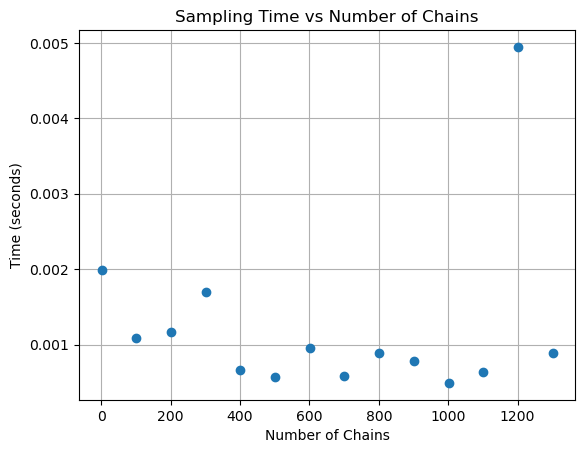

In [14]:
plt.plot(number_of_chains, times, marker='o', linestyle='')
plt.xlabel('Number of Chains')
plt.ylabel('Time (seconds)')
plt.title('Sampling Time vs Number of Chains')
plt.grid(True)